In [1]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib import pyplot as plt
import statsmodels.api as sm
import numpy as np
import itertools
import warnings
warnings.filterwarnings('ignore')

In [2]:
source_df = pd.read_json("https://doctorat.dragulin.net/api/DateModelare/prognoza?tipValoare=VenitTotal&anInceput=2016&anSfarsit=2025", orient='records')
indicatori_df = pd.read_json("https://doctorat.dragulin.net/api/DateModelare/indicatori-total?anInceput=2016&anSfarsit=2025", orient='records')

In [3]:
def optimize_arima_parameters(series, p_range, d_range, q_range, seasonal=False, P_range=None, D_range=None, Q_range=None, s=None):
    """
    Optimizează parametrii pentru modelul ARIMA/SARIMA.
    
    Parameters:
    -----------
    series : Series
        Seria temporală
    p_range, d_range, q_range : range
        Intervalele pentru parametrii non-sezonieri
    seasonal : bool
        Dacă modelul include componenta sezonieră
    P_range, D_range, Q_range : range
        Intervalele pentru parametrii sezonieri
    s : int
        Perioada sezonieră
    
    Returns:
    --------
    best_params : tuple
        Parametrii optimi (p, d, q) sau (p, d, q, P, D, Q, s)
    """
    best_aic = float('inf')
    best_params = None
    
    if not seasonal:
        # Optimizare pentru ARIMA
        for p, d, q in itertools.product(p_range, d_range, q_range):
            try:
                model = ARIMA(series, order=(p, d, q))
                results = model.fit()
                
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_params = (p, d, q)
                    
                    print(f"ARIMA({p},{d},{q}) - AIC: {results.aic:.4f}")
            except:
                continue
    else:
        # Optimizare pentru SARIMA
        for p, d, q, P, D, Q in itertools.product(p_range, d_range, q_range, P_range, D_range, Q_range):
            try:
                model = SARIMAX(series, order=(p, d, q), seasonal_order=(P, D, Q, s))
                results = model.fit()
                
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_params = (p, d, q, P, D, Q, s)
                    
                    print(f"SARIMA({p},{d},{q})({P},{D},{Q},{s}) - AIC: {results.aic:.4f}")
            except:
                continue
    
    return best_params

In [4]:
def arima_model(df, test_size=0.2, seasonal=False):
    """
    Implementează și evaluează modelul ARIMA/SARIMA.
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame cu coloanele 'Data' și 'Valoare'
    test_size : float
        Proporția datelor pentru testare (0.0 - 1.0)
    seasonal : bool
        Dacă modelul include componenta sezonieră
    
    Returns:
    --------
    y_true, y_pred, test_dates
    """
    # Pregătirea datelor
    series = df.set_index('Data')['Valoare']
    
    # Împărțirea în date de antrenare și testare
    split_idx = int(len(series) * (1 - test_size))
    train_data = series[:split_idx]
    test_data = series[split_idx:]
    
    # Optimizarea parametrilor
    if not seasonal:
        # Pentru ARIMA
        best_params = optimize_arima_parameters(
            train_data,
            p_range=range(0, 4),
            d_range=range(0, 3),
            q_range=range(0, 4),
            seasonal=False
        )
        
        if best_params:
            p, d, q = best_params
            print(f"\nParametri optimi ARIMA: ({p}, {d}, {q})")
            
            # Antrenarea modelului
            model = ARIMA(train_data, order=(p, d, q))
            model_fit = model.fit()
            
            # Generarea predicțiilor
            predictions = model_fit.forecast(steps=len(test_data))
        else:
            print("Nu s-au putut găsi parametri optimi pentru ARIMA. Se folosesc parametri impliciți (1,1,1).")
            model = ARIMA(train_data, order=(1, 1, 1))
            model_fit = model.fit()
            predictions = model_fit.forecast(steps=len(test_data))
    else:
        # Pentru SARIMA
        s = 12  # Perioada sezonieră (12 pentru date lunare)

        best_params = (3, 1, 2, 1, 2, 1, 12)
        
        # best_params = optimize_arima_parameters(
        #     train_data,
        #     p_range=range(0, 4),
        #     d_range=range(0, 3),
        #     q_range=range(0, 3),
        #     seasonal=True,
        #     P_range=range(0, 3),
        #     D_range=range(0, 3),
        #     Q_range=range(0, 2),
        #     s=s
        # )
        
        if best_params:
            p, d, q, P, D, Q, s = best_params
            print(f"\nParametri optimi SARIMA: ({p}, {d}, {q})({P}, {D}, {Q}, {s})")
            
            # Antrenarea modelului
            model = SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, s))
            model_fit = model.fit()
            
            # Generarea predicțiilor
            predictions = model_fit.forecast(steps=len(test_data))
        else:
            print("Nu s-au putut găsi parametri optimi pentru SARIMA. Se folosesc parametri impliciți (1,1,1)(1,1,1,12).")
            model = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
            model_fit = model.fit()
            predictions = model_fit.forecast(steps=len(test_data))
    
    # Normalizarea datelor pentru comparație
    scaler = MinMaxScaler()
    y_true = scaler.fit_transform(test_data.values.reshape(-1, 1)).flatten()
    y_pred = scaler.transform(predictions.values.reshape(-1, 1)).flatten()
    
    return y_true, y_pred, test_data.index

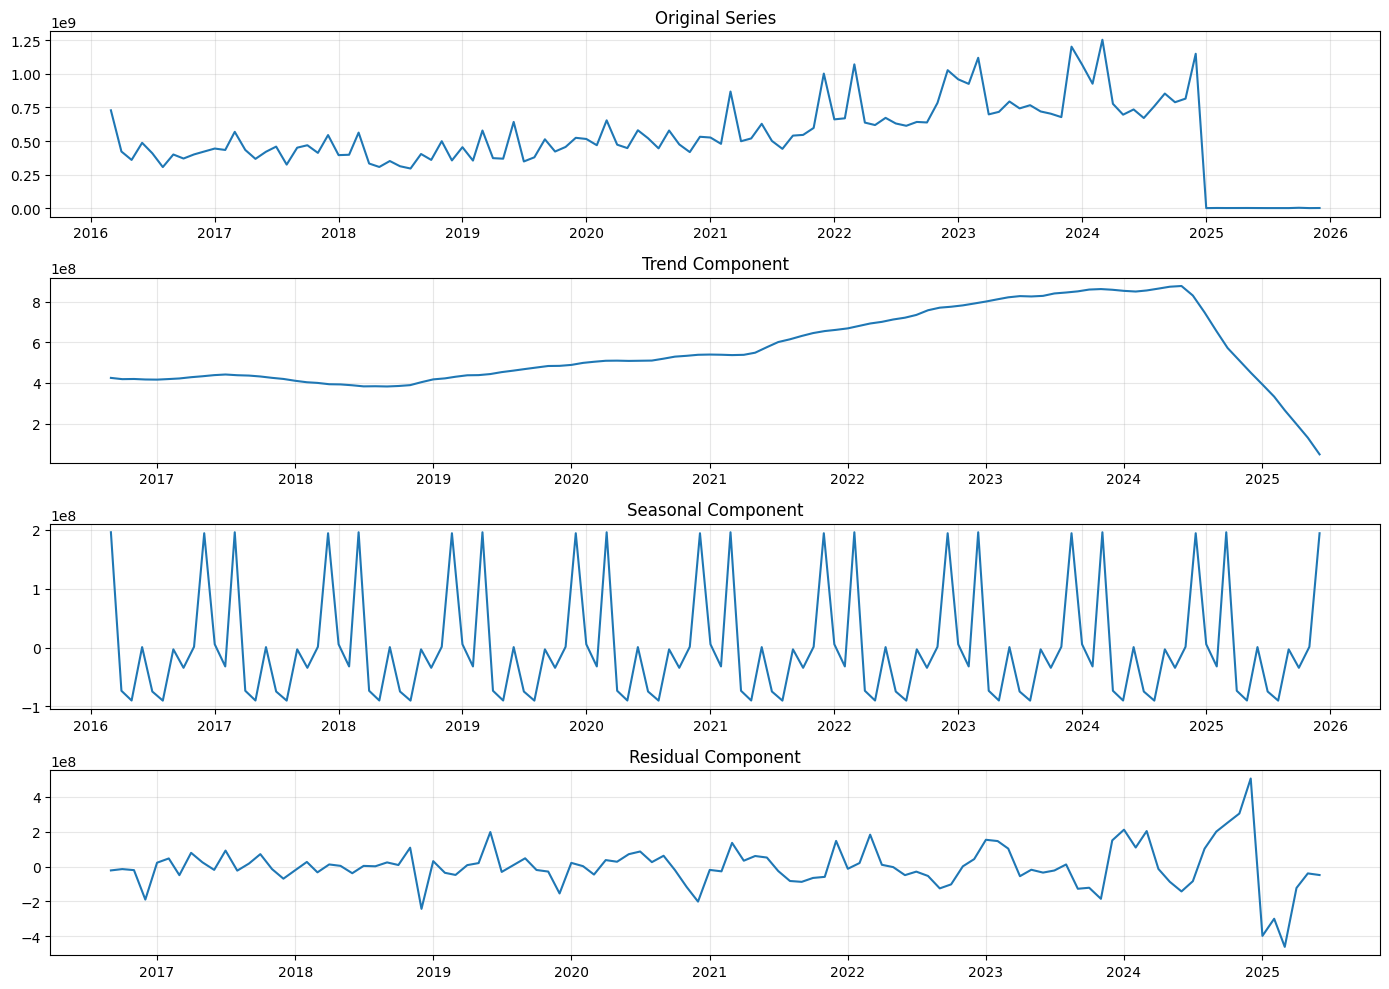

In [5]:
import matplotlib.dates as mdates

df = source_df.copy()
df['Data'] = pd.to_datetime(
    df['Data'].astype(str).str[:19],  # taie eventuale microsecunde/tz
    format='%Y-%m-%dT%H:%M:%S',
    errors='coerce'
)
df = df.dropna(subset=['Data']).sort_values('Data')

series = df.set_index('Data')['Valoare'].asfreq('MS')
decomposition = seasonal_decompose(series, period=12, model='additive')

# Afișarea componentelor
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Serie originală
axes[0].plot(series)
axes[0].set_title('Original Series')
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(decomposition.trend)
axes[1].set_title('Trend Component')
axes[1].grid(True, alpha=0.3)

# Sezonieră
axes[2].plot(decomposition.seasonal)
axes[2].set_title('Seasonal Component')
axes[2].grid(True, alpha=0.3)

# Reziduu
axes[3].plot(decomposition.resid)
axes[3].set_title('Residual Component')
axes[3].grid(True, alpha=0.3)

# === Formatăm axa X să afișeze doar anii ===
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())         # un tick pe an
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # afișează doar anul
    #ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [6]:
model = arima_model(source_df, seasonal=True)


Parametri optimi SARIMA: (3, 1, 2)(1, 2, 1, 12)


                                      SARIMAX Results                                      
Dep. Variable:                             Valoare   No. Observations:                  118
Model:             SARIMAX(3, 1, 2)x(1, 2, [], 12)   Log Likelihood               -1905.800
Date:                             Mon, 29 Jun 2026   AIC                           3825.600
Time:                                     00:16:54   BIC                           3843.328
Sample:                                 03-01-2016   HQIC                          3832.758
                                      - 12-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8641      0.550      1.570      0.116      -0.215       1.943
ar.L2         -0.1368      

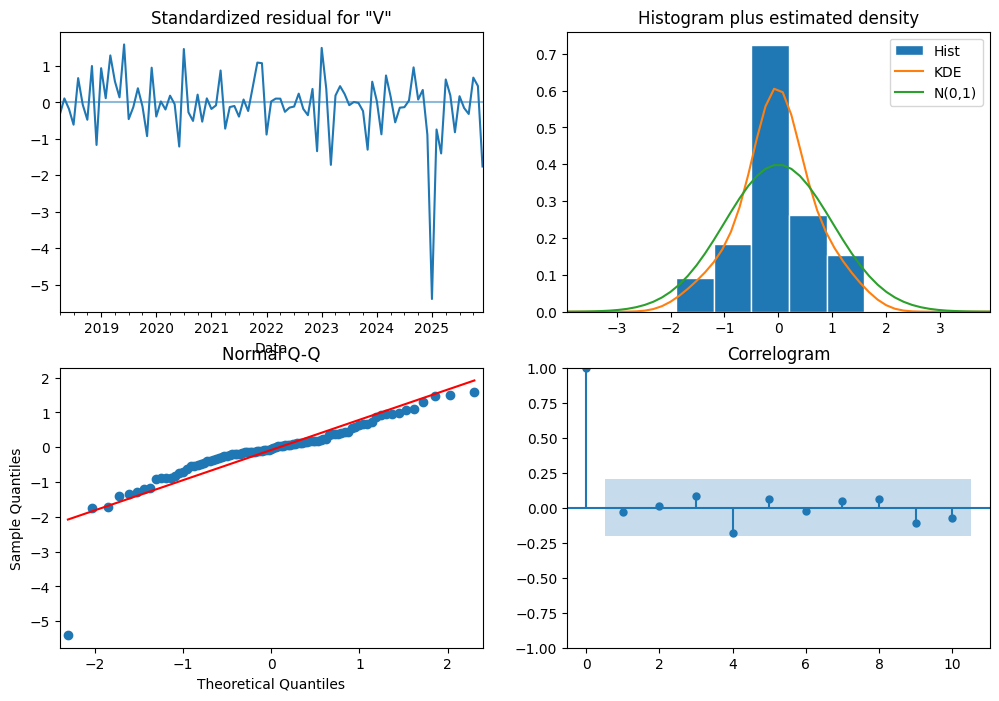

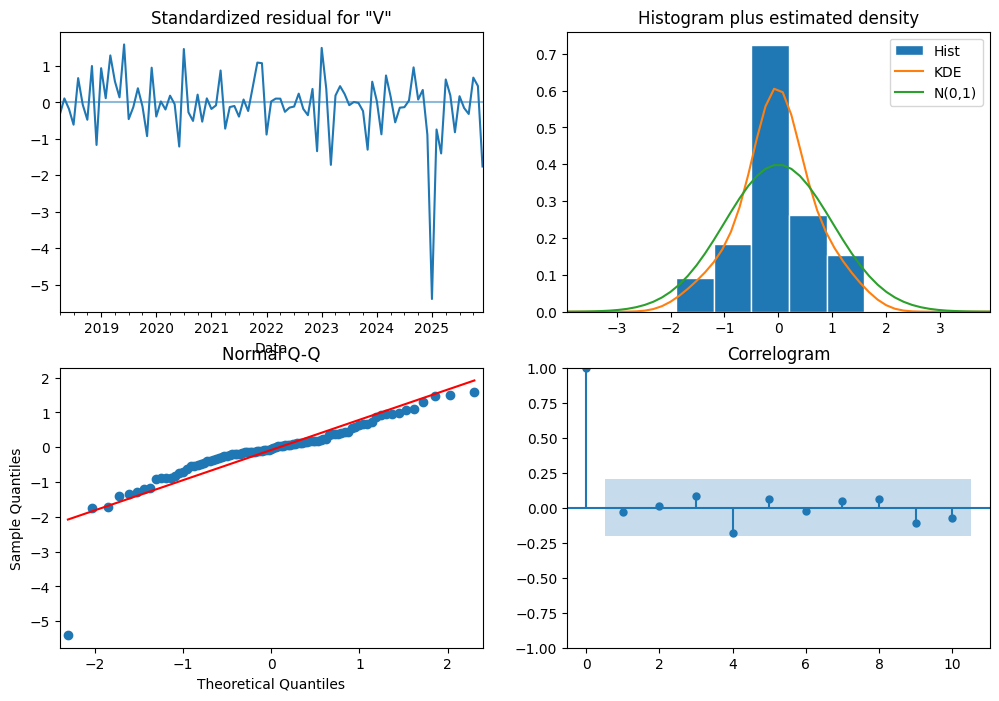

In [7]:
model = sm.tsa.SARIMAX(series, order=(3, 1, 2), seasonal_order=(1, 2, 0, 12))
result = model.fit()
print(result.summary())
result.plot_diagnostics(figsize=(12,8))

In [8]:
def fit_sarima(series, order, seasonal_order, trend='n'):
    """
    Întoarce (result, info_dict) sau (None, info_dict cu eroare)
    """
    try:
        model = sm.tsa.SARIMAX(
            series,
            order=order,
            seasonal_order=seasonal_order,
            trend=trend,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False)
        info = {
            'order': order,
            'seasonal_order': seasonal_order,
            'aic': res.aic,
            'bic': res.bic,
            'hqic': getattr(res, 'hqic', np.nan),
            'nobs': res.nobs,
            'converged': res.mle_retvals.get('converged', True),
            'n_params': res.params.size
        }
        return res, info
    except Exception as e:
        return None, {
            'order': order, 'seasonal_order': seasonal_order,
            'aic': np.inf, 'bic': np.inf, 'hqic': np.inf,
            'nobs': len(series), 'converged': False, 'n_params': np.nan,
            'error': str(e)
        }

In [9]:
def grid_search_sarima(series,
                       p_range=range(0,5), d_range=range(0,5), q_range=range(0,5),
                       P_range=range(0,4), D_range=range(0,4), Q_range=range(0,4),
                       s=12, trend='n'):
    """
    Caută pe grilă și întoarce (df_rezultate, topK_models)
    topK_models este listă de tuples (result, info) pentru primele 3 după AIC
    """
    rows = []
    fitted = []  # păstrăm câteva rezultate bune pentru diagrame
    combos = list(itertools.product(p_range, d_range, q_range,
                                    P_range, D_range, Q_range))
    total = len(combos)
    print(f"Combinații de testat: {total}")

    for idx, (p,d,q,P,D,Q) in enumerate(combos, 1):
        order = (p,d,q)
        seas  = (P,D,Q,s)
        res, info = fit_sarima(series, order, seas, trend=trend)
        rows.append(info)

        # păstrăm doar modelele care au mers și nu au AIC inf
        if res is not None and np.isfinite(info['aic']):
            fitted.append((res, info))

        if idx % 100 == 0 or idx == total:
            best_aic = np.nanmin([r['aic'] for r in rows]) if rows else np.nan
            print(f"[{idx}/{total}] cel mai bun AIC până acum: {best_aic:.3f}")

    df = pd.DataFrame(rows).sort_values('aic', ascending=True).reset_index(drop=True)
    fitted_sorted = sorted(fitted, key=lambda t: t[1]['aic'])[:3]
    return df, fitted_sorted

In [10]:
def holdout_eval(series, order, seasonal_order, h=12, trend='n'):
    """
    Împarte seria în train/test (ultimele h ca test), antrenează pe train,
    face forecast pe h pași și calculează RMSE & MAPE.
    """
    if len(series) <= 2*h:
        h = max(1, len(series)//5)  # fallback dacă seria e scurtă

    train, test = series.iloc[:-h], series.iloc[-h:]

    res, _ = fit_sarima(train, order, seasonal_order, trend=trend)
    if res is None:
        return None, None, None

    fc = res.forecast(steps=h)
    # aliniem indicii (în caz că lipsesc câteva luni)
    fc = fc.reindex(test.index)

    print(result.summary())
    
    print("Test values:")
    print(test.values)

    print("Forecast values:")
    print(fc.values)

    rmse = float(np.sqrt(np.mean((fc.values - test.values)**2)))
    mape = float(np.mean(np.abs((test.values - fc.values) / np.where(test.values==0, np.nan, test.values))) * 100)
    return fc, rmse, mape

Combinații de testat: 12


[12/12] cel mai bun AIC până acum: 3203.092

TOP 10 modele după AIC:
       order seasonal_order          aic          bic         hqic  converged
0  (3, 1, 2)  (1, 2, 1, 12)  3203.092281  3221.945951  3210.639751       True
1  (3, 1, 2)  (0, 2, 1, 12)  3204.492814  3220.989776  3211.096851       True
2  (3, 1, 2)  (1, 2, 0, 12)  3214.326992  3230.823953  3220.931028       True
3  (3, 1, 2)  (0, 1, 1, 12)  3661.836494  3679.335161  3668.892985       True
4  (3, 1, 2)  (1, 1, 1, 12)  3663.460834  3683.459311  3671.525396       True
5  (3, 1, 2)  (1, 1, 0, 12)  3664.409023  3681.907691  3671.465514       True
6  (3, 1, 2)  (0, 2, 0, 12)  3718.025887  3733.024745  3724.074308       True
7  (3, 1, 2)  (0, 1, 0, 12)  4147.454106  4163.203943  4153.831752       True
8  (3, 1, 2)  (1, 0, 0, 12)  4401.285844  4419.660653  4408.726431       True
9  (3, 1, 2)  (0, 0, 1, 12)  4520.381492  4538.756302  4527.822079       True

#1  order=(3, 1, 2) seasonal_order=(1, 2, 1, 12)  AIC=3203.092


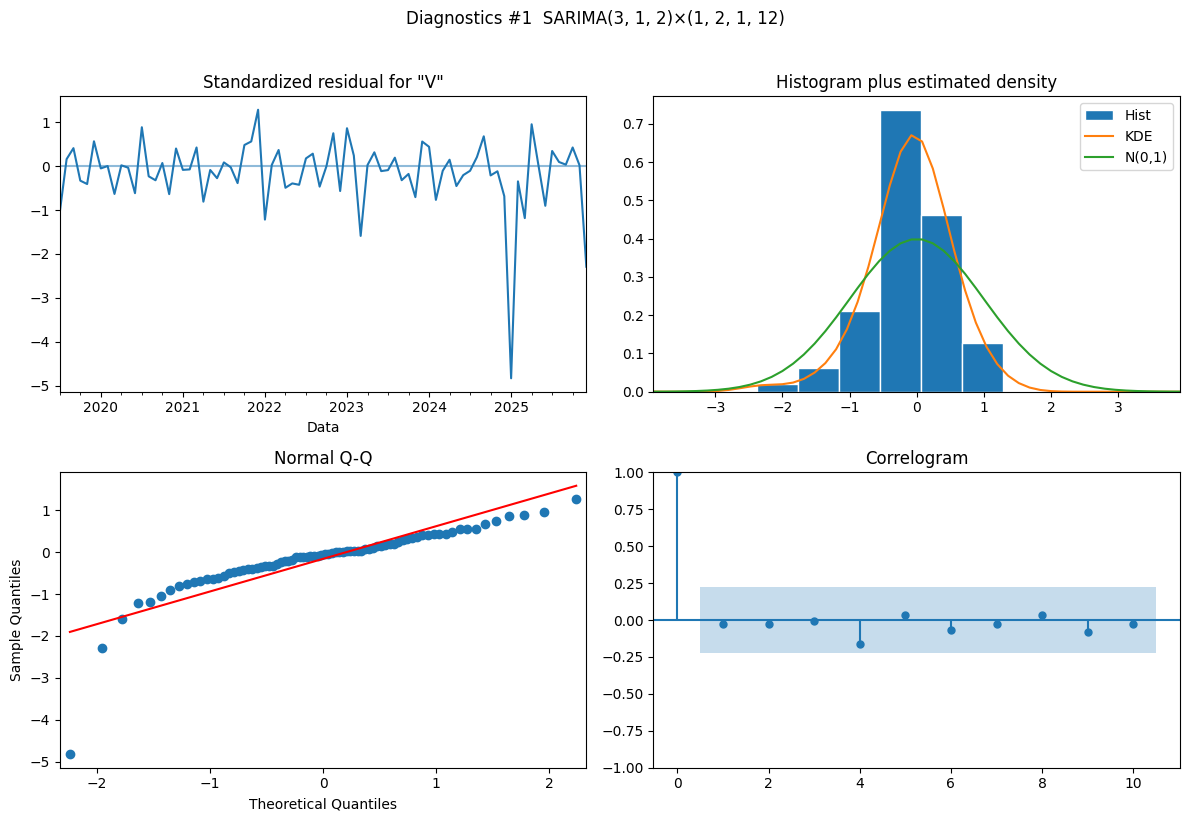


#2  order=(3, 1, 2) seasonal_order=(0, 2, 1, 12)  AIC=3204.493


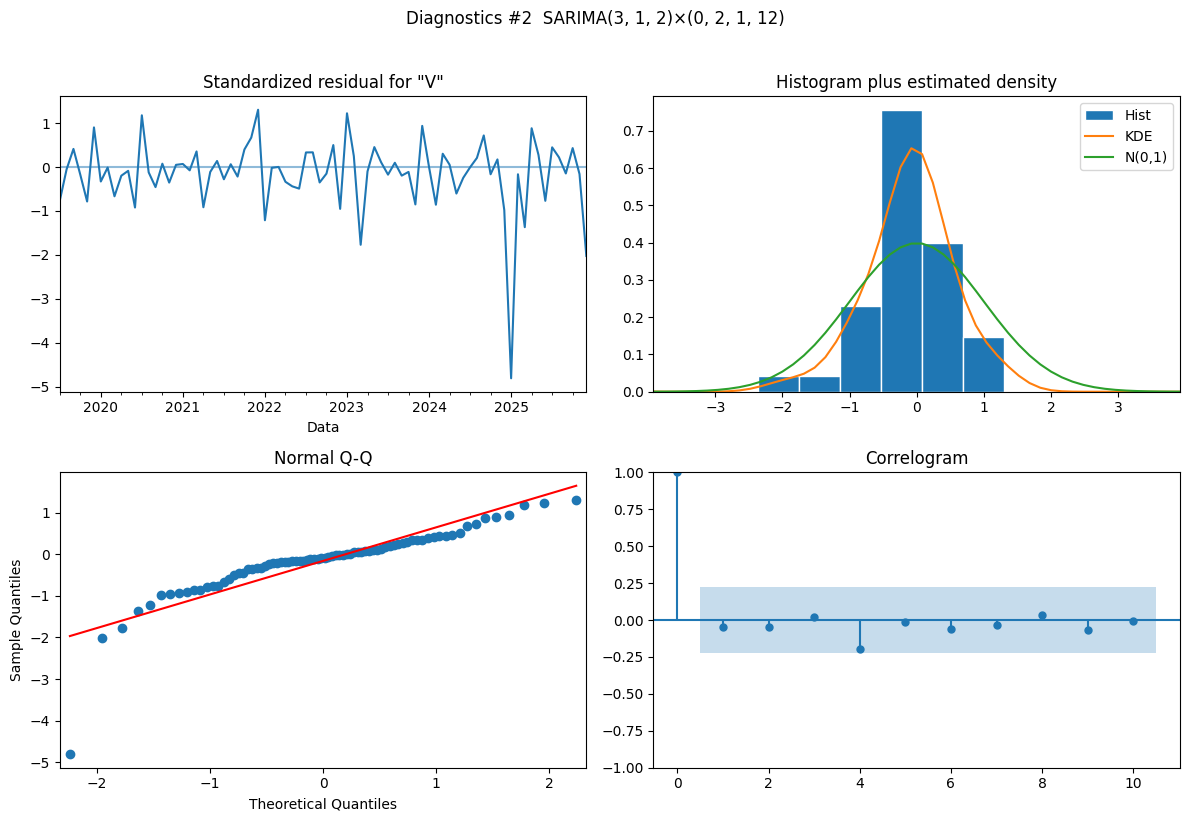


#3  order=(3, 1, 2) seasonal_order=(1, 2, 0, 12)  AIC=3214.327


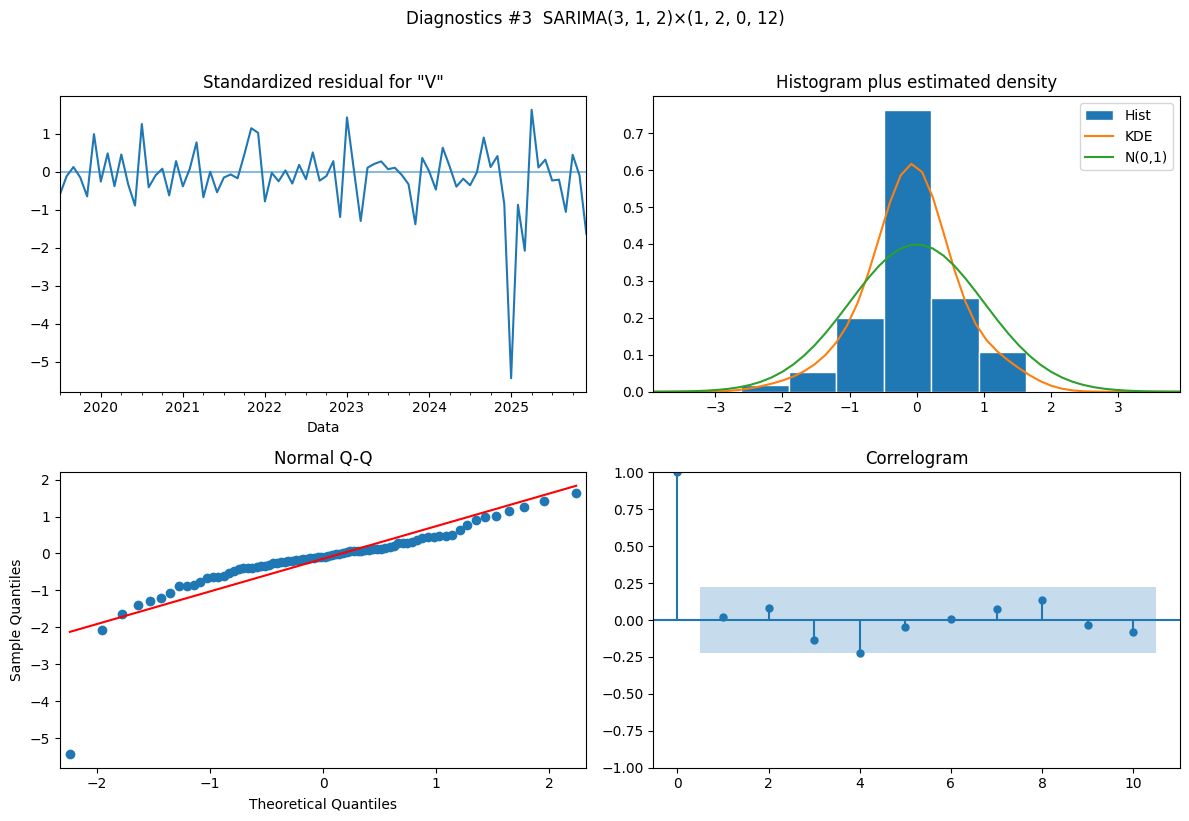

                                      SARIMAX Results                                      
Dep. Variable:                             Valoare   No. Observations:                  118
Model:             SARIMAX(3, 1, 2)x(1, 2, [], 12)   Log Likelihood               -1905.800
Date:                             Mon, 29 Jun 2026   AIC                           3825.600
Time:                                     00:17:00   BIC                           3843.328
Sample:                                 03-01-2016   HQIC                          3832.758
                                      - 12-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8641      0.550      1.570      0.116      -0.215       1.943
ar.L2         -0.1368      

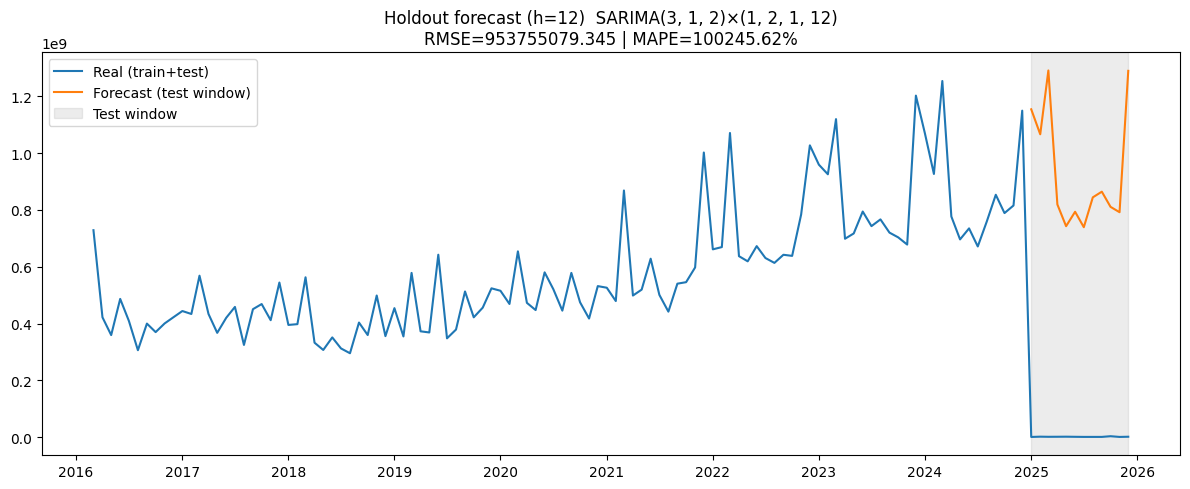

                                      SARIMAX Results                                      
Dep. Variable:                             Valoare   No. Observations:                  118
Model:             SARIMAX(3, 1, 2)x(1, 2, [], 12)   Log Likelihood               -1905.800
Date:                             Mon, 29 Jun 2026   AIC                           3825.600
Time:                                     00:17:00   BIC                           3843.328
Sample:                                 03-01-2016   HQIC                          3832.758
                                      - 12-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8641      0.550      1.570      0.116      -0.215       1.943
ar.L2         -0.1368      

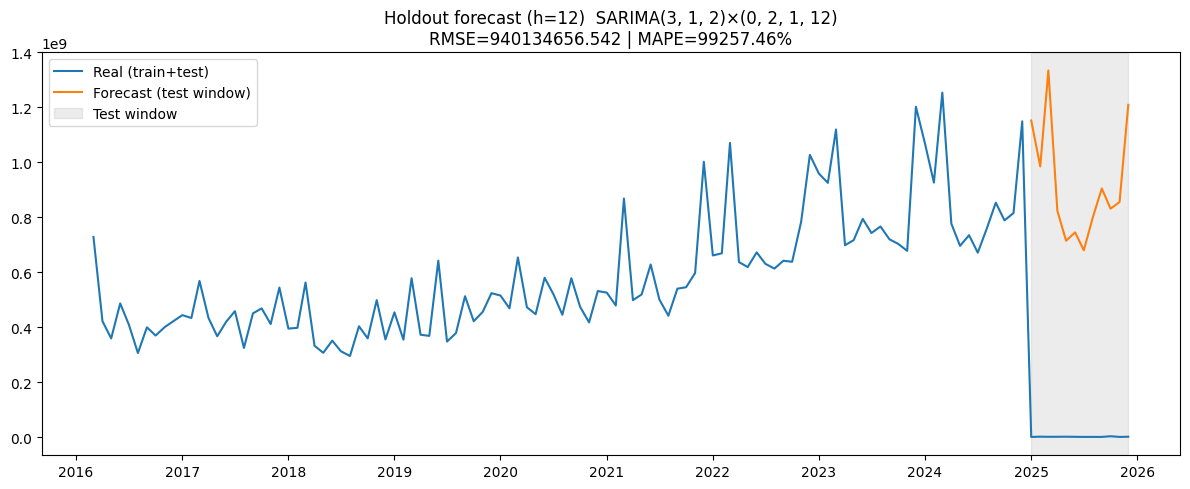

                                      SARIMAX Results                                      
Dep. Variable:                             Valoare   No. Observations:                  118
Model:             SARIMAX(3, 1, 2)x(1, 2, [], 12)   Log Likelihood               -1905.800
Date:                             Mon, 29 Jun 2026   AIC                           3825.600
Time:                                     00:17:01   BIC                           3843.328
Sample:                                 03-01-2016   HQIC                          3832.758
                                      - 12-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8641      0.550      1.570      0.116      -0.215       1.943
ar.L2         -0.1368      

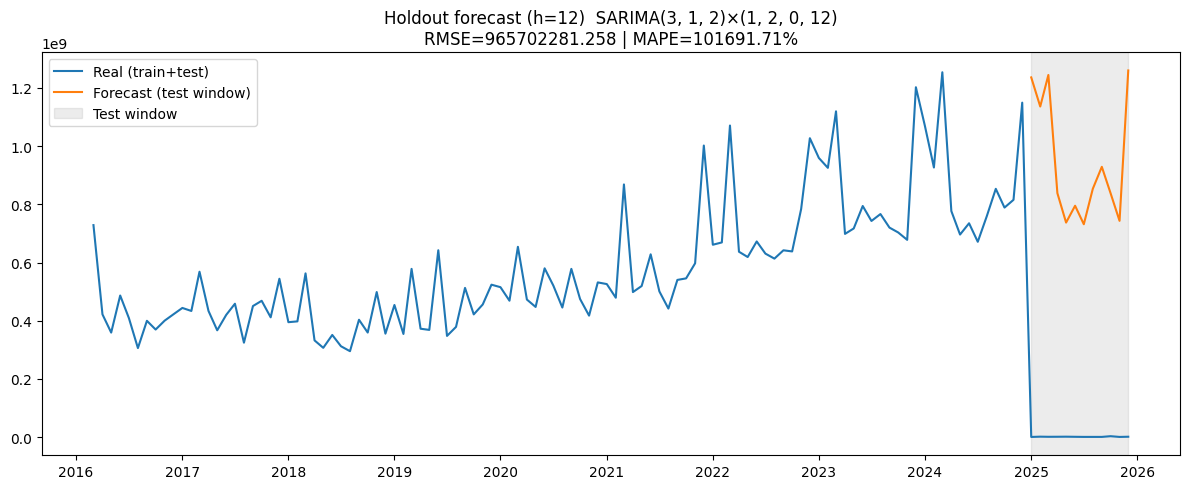

In [11]:

# ==== Rulează grid search (valorile din întrebarea ta) ====
# Atenție: 5^3 * 4^3 = 8000 de fit-uri; dacă e prea mult, restrânge intervalele.
df_results, top3 = grid_search_sarima(
    series,
    p_range=range(3,4), d_range=range(1,2), q_range=range(2,3),
    P_range=range(0,2), D_range=range(0,3), Q_range=range(0,2),
    s=12, trend='n'
)

print("\nTOP 10 modele după AIC:")
print(df_results[['order','seasonal_order','aic','bic','hqic','converged']].head(10))

# ==== Ploturi de diagnostic pentru TOP 3 ====
for rank, (res, info) in enumerate(top3, 1):
    print(f"\n#{rank}  order={info['order']} seasonal_order={info['seasonal_order']}  AIC={info['aic']:.3f}")
    fig = res.plot_diagnostics(figsize=(12, 8))
    fig.suptitle(f"Diagnostics #{rank}  SARIMA{info['order']}×{info['seasonal_order']}", y=1.02)
    plt.tight_layout()
    plt.show()

# ==== Evaluare out-of-sample (ultimele 12 luni) pentru TOP 3 ====
for rank, (_, info) in enumerate(top3, 1):
    order, seas = info['order'], info['seasonal_order']
    fc, rmse, mape = holdout_eval(series, order, seas, h=12, trend='n')
    if fc is None:
        print(f"#{rank} evaluare eșuată pentru {order}×{seas}")
        continue

    print(f"#{rank}  {order}×{seas}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

    # Plot comparativ train/test
    test = series.iloc[-len(fc):]
    plt.figure(figsize=(12,5))
    plt.plot(series.index, series.values, label='Real (train+test)')
    plt.plot(fc.index, fc.values, label='Forecast (test window)')
    plt.axvspan(test.index.min(), test.index.max(), color='grey', alpha=0.15, label='Test window')
    plt.title(f"Holdout forecast (h=12)  SARIMA{order}×{seas}\nRMSE={rmse:.3f} | MAPE={mape:.2f}%")
    plt.legend()
    plt.tight_layout()
    plt.show()